# Predictive Modeling Study on New York Housing Rental Price

## I. Introduction
* Project motivation:

  NYC rent varies greatly across boroughs and changes over time. This project studies **whether historical rent trends can predict future rental prices**.

* Data overview:

  We use [Zillow Observed Rent Index (ZORI)](https://www.zillow.com/research/data/) monthly data at the ZIP-code level. Each row represents one ZIP code in one month.


* Exploratory Data Analysis:

  Before building prediction models, we use EDA to understand **rent patterns across boroughs, ZIP codes, and time**. The visualizations help identify spatial rent differences, post-2020 rent changes, and the special position of Long Island City within Queens. These patterns motivate our later hypothesis that historical rent values and location-related features can help predict future rent.



* Predictive task:

  The main task is to **predict next month’s rent index** using current rent, lagged rent values, rent growth, time features, borough, and a Long Island City indicator.

* Models used:

  We compare Linear Regression, Ridge Regression, KNN Regression, Random Forest Regression, Logistic Regression classification, and time-series forecasting models including ARIMA and Exponential Smoothing.

* Summary findings:

  * **Linear Regression performs best for rent prediction**.
  
  * **Logistic Regression performs best for high-rent classification**.
  
  * **Exponential Smoothing performs best in the forecasting extension**.




## II. Data Description and Data Preparation

We use [Zillow Observed Rent Index data](https://www.zillow.com/research/data/) (ZORI) at the ZIP-code-month level. After filtering to New York City ZIP codes, we transform the data from wide to long format and create lag features from past rent values. The predictive task is to estimate next month’s rent index using current rent, previous rent levels, rent growth, borough, and time features.

***Note**: Here's a link to [the methodology of how ZORI is calculated](https://www.zillow.com/research/methodology-zori-repeat-rent-27092/).

In one sentense, ZORI is a repeat-rent index that measures the typical, observed market-rate rent across a given region

### 1. Access Dataset and Build DataFrame



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the data
zori_raw = pd.read_csv("/content/zori_zip.csv")

print(zori_raw.shape)
zori_raw.head()


(8188, 144)


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2015-01-31,...,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31
0,91982,1,77494,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,1396.420611,...,1752.349869,1761.399334,1768.181320,1762.748802,1752.914282,1739.839933,1735.345787,1716.202697,1704.095737,1683.654847
1,61148,2,8701,zip,NJ,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA",Ocean County,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2305.088360,2379.926927,2310.000000
2,91940,3,77449,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Harris County,1238.667257,...,1825.135558,1823.161847,1814.078021,1805.419803,1804.616865,1793.828474,1804.151902,1793.823253,1797.458821,1779.454743
3,62080,4,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2700.000000
4,91733,5,77084,zip,TX,TX,Houston,"Houston-The Woodlands-Sugar Land, TX",Harris County,1093.863007,...,1576.421608,1573.457268,1579.511547,1579.319611,1574.482724,1564.271077,1559.644039,1559.997423,1554.930010,1544.184291


In [ ]:
# check columns
zori_raw.columns.tolist()[:15]

['RegionID',
 'SizeRank',
 'RegionName',
 'RegionType',
 'StateName',
 'State',
 'City',
 'Metro',
 'CountyName',
 '2015-01-31',
 '2015-02-28',
 '2015-03-31',
 '2015-04-30',
 '2015-05-31',
 '2015-06-30']

### 2. Data Cleaning


In [ ]:
# Filter to NYC ZIP codes
nyc_counties = [
    "New York County",   # Manhattan
    "Kings County",      # Brooklyn
    "Queens County",     # Queens
    "Bronx County",      # Bronx
    "Richmond County"    # Staten Island
]

zori_nyc = zori_raw[
    (zori_raw["StateName"] == "NY") &
    (zori_raw["CountyName"].isin(nyc_counties))
].copy()

print(zori_nyc.shape)
zori_nyc.head()

(152, 144)


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2015-01-31,...,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31
3,62080,4,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2700.000000
6,62093,7,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,NaN,...,3044.561878,3110.006786,3089.504783,3071.414298,3031.055703,3014.708892,2973.686373,3010.333460,3059.504855,3110.629630
8,62019,9,11208,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Kings County,NaN,...,2845.342594,2909.551010,3016.331449,3072.160061,3155.939273,3205.441432,3065.921897,2976.415274,3017.804947,3076.214286
15,62046,16,11236,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Kings County,NaN,...,NaN,NaN,2857.114308,2958.952092,3128.457579,3180.443234,3064.320348,3156.161825,3143.126917,3162.500000
16,61807,17,10467,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Bronx County,NaN,...,2416.595951,2534.798815,2606.677096,2530.246942,2581.748354,2558.887553,2569.694683,2487.993981,2545.825631,2629.875000


In [ ]:
# Add borough
county_to_borough = {
    "New York County": "Manhattan",
    "Kings County": "Brooklyn",
    "Queens County": "Queens",
    "Bronx County": "Bronx",
    "Richmond County": "Staten Island"
}

zori_nyc["borough"] = zori_nyc["CountyName"].map(county_to_borough)

### 3. Feature engineering

**Convert from wide to long format**

In [ ]:
# turns many monthly columns into one date column and one zori_rent column
id_cols = [
    "RegionID",
    "SizeRank",
    "RegionName",
    "RegionType",
    "StateName",
    "State",
    "City",
    "Metro",
    "CountyName",
    "borough"
]

date_cols = [col for col in zori_nyc.columns if col not in id_cols]

zori_long = zori_nyc.melt(
    id_vars=id_cols,
    value_vars=date_cols,
    var_name="date",
    value_name="zori_rent"
)

zori_long["date"] = pd.to_datetime(zori_long["date"], errors="coerce")
zori_long = zori_long.dropna(subset=["date", "zori_rent"])

zori_long = zori_long.rename(columns={
    "RegionName": "zip_code",
    "CountyName": "county"
})

zori_long["zip_code"] = zori_long["zip_code"].astype(str)

print(zori_long.shape)
zori_long.head()

(12541, 12)


,RegionID,SizeRank,zip_code,RegionType,StateName,State,City,Metro,county,borough,date,zori_rent
6,62037,19,11226,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Kings County,Brooklyn,2015-01-31,1876.767896
7,62018,20,11207,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Kings County,Brooklyn,2015-01-31,1771.672139
8,61639,29,10025,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,Manhattan,2015-01-31,3044.118997
14,62017,47,11206,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Kings County,Brooklyn,2015-01-31,2435.755684
15,62032,48,11221,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Kings County,Brooklyn,2015-01-31,1964.510744


**Create lag feature**

These are the most important predictive features.

Rent is highly **time-dependent**. The best predictor of next month’s rent is often this month’s rent and recent rent trend.

So, instead of predicting with only:

  * borough, month, year

we  predict with:

  * current rent

  * last month’s rent

  * rent 3 months ago

  * rent 12 months ago

  * recent growth

  * seasonality

  * borough




In [ ]:
# create time features
zori_long["year"] = zori_long["date"].dt.year
zori_long["month"] = zori_long["date"].dt.month
zori_long["quarter"] = zori_long["date"].dt.quarter
zori_long = zori_long.sort_values(["zip_code", "date"])

# create lag features
zori_long["rent_lag_1"] = zori_long.groupby("zip_code")["zori_rent"].shift(1)
zori_long["rent_lag_2"] = zori_long.groupby("zip_code")["zori_rent"].shift(2)
zori_long["rent_lag_3"] = zori_long.groupby("zip_code")["zori_rent"].shift(3)
zori_long["rent_lag_12"] = zori_long.groupby("zip_code")["zori_rent"].shift(12)

# create rent growth features
zori_long["rent_growth_1m"] = (
    zori_long["zori_rent"] - zori_long["rent_lag_1"]
) / zori_long["rent_lag_1"]
zori_long["rent_growth_12m"] = (
    zori_long["zori_rent"] - zori_long["rent_lag_12"]
) / zori_long["rent_lag_12"]

# create target variable
zori_long["target_next_month_rent"] = (
    zori_long.groupby("zip_code")["zori_rent"].shift(-1)
)

# create is_lic variable
lic_zips = ["11101", "11109"]
zori_long["is_lic"] = zori_long["zip_code"].astype(str).isin(lic_zips).astype(int)
zori_long["zip_code"] = zori_long["zip_code"].astype(str)


model_df = zori_long.dropna(subset=[
    "zori_rent",
    "rent_lag_1",
    "rent_lag_2",
    "rent_lag_3",
    "rent_lag_12",
    "rent_growth_1m",
    "rent_growth_12m",
    "target_next_month_rent",
    "is_lic"
]).copy()

print(model_df.shape)
model_df.head()

(10849, 23)


,RegionID,SizeRank,zip_code,RegionType,StateName,State,City,Metro,county,borough,...,month,quarter,rent_lag_1,rent_lag_2,rent_lag_3,rent_lag_12,rent_growth_1m,rent_growth_12m,target_next_month_rent,is_lic
1947,61615,4444,10001,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,Manhattan,...,1,1,4076.478274,4084.053297,4136.821172,3958.238156,-0.006741,0.022930,4041.609677,0
2099,61615,4444,10001,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,Manhattan,...,2,1,4048.999810,4076.478274,4084.053297,3989.656803,-0.001825,0.013022,4056.968346,0
2251,61615,4444,10001,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,Manhattan,...,3,1,4041.609677,4048.999810,4076.478274,3996.446526,0.003800,0.015144,4087.752041,0
2403,61615,4444,10001,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,Manhattan,...,4,2,4056.968346,4041.609677,4048.999810,4073.226094,0.007588,0.003566,4139.052840,0
2555,61615,4444,10001,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,Manhattan,...,5,2,4087.752041,4056.968346,4041.609677,4143.042151,0.012550,-0.000963,4150.624433,0


**Final Model DataFrame**

In [ ]:
final_cols = [
    "zip_code",
    "borough",
    "city",
    "county",
    "date",
    "year",
    "month",
    "quarter",
    "zori_rent",
    "rent_lag_1",
    "rent_lag_2",
    "rent_lag_3",
    "rent_lag_12",
    "rent_growth_1m",
    "rent_growth_12m",
    "target_next_month_rent",
    "is_lic" # Add is_lic to final_cols
]

# Ensure 'City' is renamed to 'city' in model_df
# model_df is assumed to already contain 'is_lic' from its creation based on zori_long
model_df = model_df.rename(columns={"City": "city"})

# Now model_df should have 'city' (lowercase) and 'is_lic'
model_df_final = model_df[final_cols].copy()

print(model_df_final.shape)
model_df_final.head()

(10849, 17)


,zip_code,borough,city,county,date,year,month,quarter,zori_rent,rent_lag_1,rent_lag_2,rent_lag_3,rent_lag_12,rent_growth_1m,rent_growth_12m,target_next_month_rent,is_lic
1947,10001,Manhattan,New York,New York County,2016-01-31,2016,1,1,4048.999810,4076.478274,4084.053297,4136.821172,3958.238156,-0.006741,0.022930,4041.609677,0
2099,10001,Manhattan,New York,New York County,2016-02-29,2016,2,1,4041.609677,4048.999810,4076.478274,4084.053297,3989.656803,-0.001825,0.013022,4056.968346,0
2251,10001,Manhattan,New York,New York County,2016-03-31,2016,3,1,4056.968346,4041.609677,4048.999810,4076.478274,3996.446526,0.003800,0.015144,4087.752041,0
2403,10001,Manhattan,New York,New York County,2016-04-30,2016,4,2,4087.752041,4056.968346,4041.609677,4048.999810,4073.226094,0.007588,0.003566,4139.052840,0
2555,10001,Manhattan,New York,New York County,2016-05-31,2016,5,2,4139.052840,4087.752041,4056.968346,4041.609677,4143.042151,0.012550,-0.000963,4150.624433,0


## III. Exploratory Data Analysis

### 1. Main Features


*   monthly rent index
*   borough
*   ZIP code
*   LIC vs other Queens
*   year
*   month
*   rent growth

In [ ]:
# Choose features for EDA
eda_df = zori_long[
    [
        "zip_code",
        "borough",
        "date",
        "year",
        "month",
        "zori_rent",
        "rent_growth_1m",
        "rent_growth_12m",
        "is_lic"
    ]
].copy()

# Create LIC vs other Queens group
lic_vs_queens = zori_long[
    (zori_long["borough"] == "Queens") | (zori_long["is_lic"] == 1)
].copy()

lic_vs_queens["area_group"] = np.where(
    lic_vs_queens["is_lic"] == 1,
    "Long Island City",
    "Other Queens"
)

print(eda_df.shape)
eda_df.head()

(12541, 9)


,zip_code,borough,date,year,month,zori_rent,rent_growth_1m,rent_growth_12m,is_lic
123,10001,Manhattan,2015-01-31,2015,1,3958.238156,NaN,NaN,0
275,10001,Manhattan,2015-02-28,2015,2,3989.656803,0.007938,NaN,0
427,10001,Manhattan,2015-03-31,2015,3,3996.446526,0.001702,NaN,0
579,10001,Manhattan,2015-04-30,2015,4,4073.226094,0.019212,NaN,0
731,10001,Manhattan,2015-05-31,2015,5,4143.042151,0.017140,NaN,0


### 2. Visualization

***Note on ZORI rent values:**  
The rental price variable in this project is based on Zillow Observed Rent Index (ZORI). ZORI represents a typical observed market rent at the ZIP-code level, not the simple average rent of all currently listed apartments. Because it reflects broader market-level trends across housing units and property types, its values may look lower than the rents commonly seen on rental platforms, especially for popular or luxury one-bedroom apartments in Manhattan. Therefore, we interpret ZORI mainly as a comparable rent index for analyzing borough-level, ZIP-code-level, and time-series patterns.

**Rent trend over time by borough**

The rent trend shows that Manhattan consistently has the highest rent level, followed by Brooklyn and Queens. All boroughs experienced a clear rent drop around 2020–2021, likely reflecting the pandemic-period rental market shock, followed by a strong recovery and continued growth after 2021.

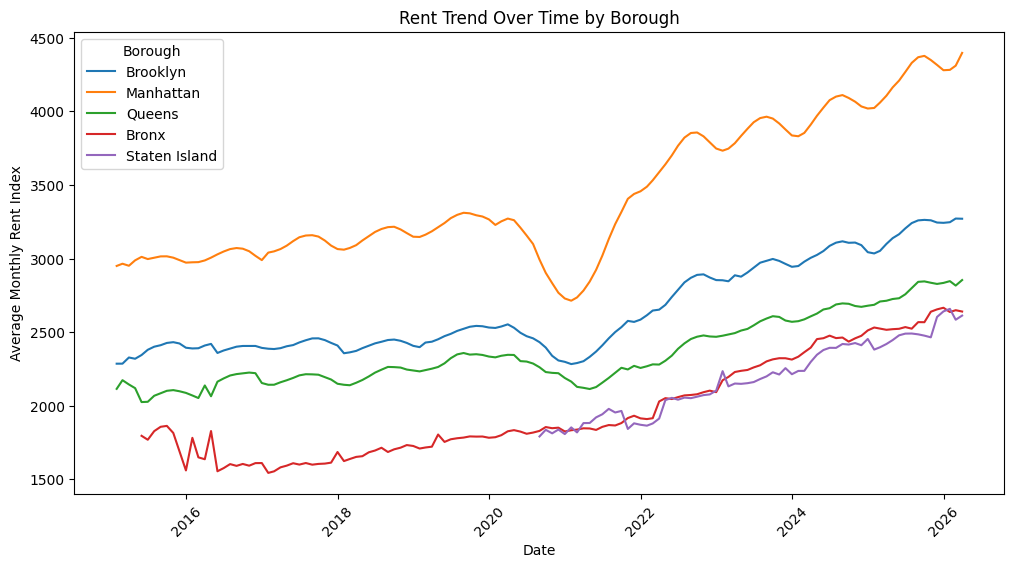

In [ ]:
# Average monthly rent trend by borough
borough_rent_trend = (
    eda_df
    .groupby(["date", "borough"])
    .agg(avg_rent=("zori_rent", "mean"))
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=borough_rent_trend,
    x="date",
    y="avg_rent",
    hue="borough"
)

plt.title("Rent Trend Over Time by Borough")
plt.xlabel("Date")
plt.ylabel("Average Monthly Rent Index")
plt.xticks(rotation=45)
plt.legend(title="Borough")
plt.show()

**Average rent by borough (2026)**

In 2026, Manhattan has the highest average ZORI rent among the five boroughs, at about \$4,331. Brooklyn is the second highest, around \$3,263, followed by Queens at about \$2,840. The Bronx and Staten Island have the lowest average rents, both around \$2,600. Overall, the result shows a clear rent gap between Manhattan and the other boroughs, while Brooklyn and Queens form a middle-rent group and the Bronx/Staten Island remain relatively more affordable.

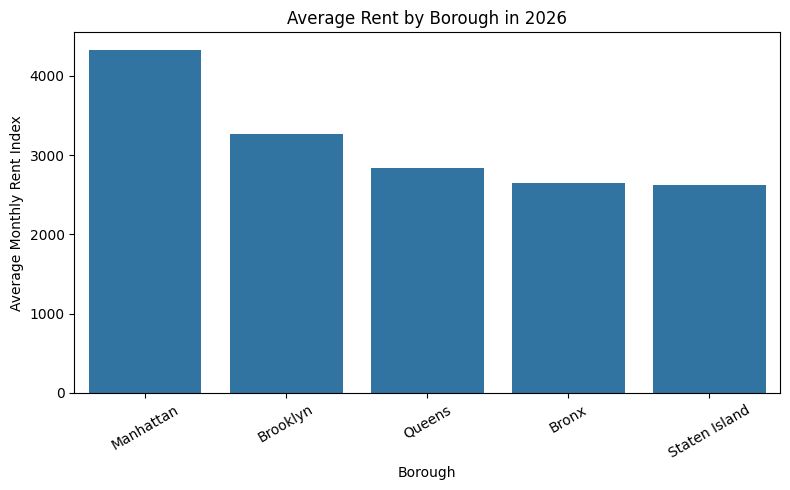

,borough,avg_rent
2,Manhattan,4330.982463
1,Brooklyn,3263.439071
3,Queens,2840.053053
0,Bronx,2641.883506
4,Staten Island,2620.015243


In [ ]:
# Average rent by borough in 2026
rent_2026 = eda_df[eda_df["year"] == 2026].copy()

rent_by_borough_2026 = (
    rent_2026
    .groupby("borough")
    .agg(avg_rent=("zori_rent", "mean"))
    .reset_index()
    .sort_values("avg_rent", ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=rent_by_borough_2026,
    x="borough",
    y="avg_rent"
)

plt.title("Average Rent by Borough in 2026")
plt.xlabel("Borough")
plt.ylabel("Average Monthly Rent Index")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

rent_by_borough_2026

**Rent distribution (2026)**

The 2026 rent distribution shows that Manhattan has both the highest rent level and the widest spread. Most Manhattan ZIP-code observations are above \$4,000, with some high-rent areas reaching over \$7,000. Queens, the Bronx, and Staten Island are more concentrated around \$2,500–\$3,000, suggesting relatively lower and more stable rent levels. Brooklyn falls between these groups: its rent distribution overlaps with Queens in the lower range, but also extends toward higher values, showing greater variation across neighborhoods. Overall, the distribution confirms that Manhattan is the most expensive and least homogeneous borough in terms of rent.


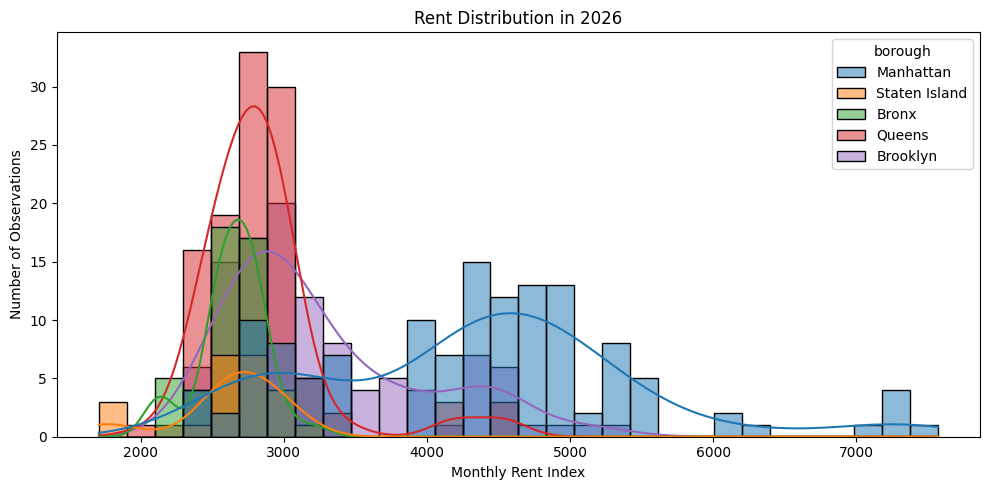

In [ ]:
# Rent distribution in 2026
rent_2026 = eda_df[eda_df["year"] == 2026].copy()

plt.figure(figsize=(10, 5))
sns.histplot(
    data=rent_2026,
    x="zori_rent",
    hue="borough",
    bins=30,
    kde=True
)

plt.title("Rent Distribution in 2026")
plt.xlabel("Monthly Rent Index")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

**Monthly rent growth trend**

Rent growth dropped sharply around 2020, especially in the 12-month growth rate, reflecting the COVID-era rental market shock. After 2021, rent growth rebounded quickly and peaked around 2022. Since then, growth has slowed but remained mostly positive through 2026.


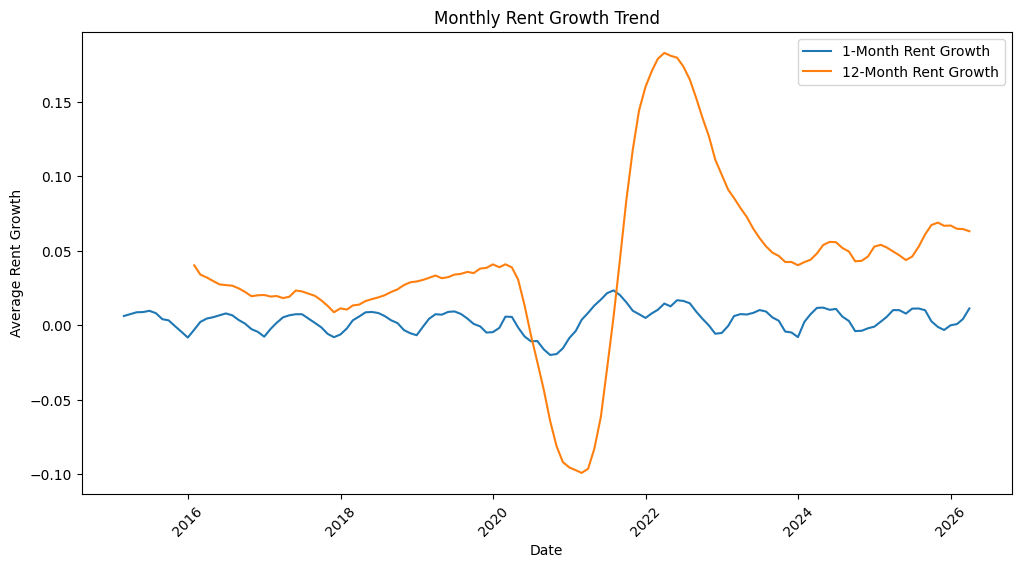

,date,avg_rent_growth_1m,avg_rent_growth_12m
132,2026-01-31,0.000869,0.064785
133,2026-02-28,0.004220,0.064610
134,2026-03-31,0.011344,0.063161


In [ ]:
# Monthly rent growth trend
monthly_growth_trend = (
    eda_df
    .groupby("date")
    .agg(
        avg_rent_growth_1m=("rent_growth_1m", "mean"),
        avg_rent_growth_12m=("rent_growth_12m", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_growth_trend["date"],
    monthly_growth_trend["avg_rent_growth_1m"],
    label="1-Month Rent Growth"
)

plt.plot(
    monthly_growth_trend["date"],
    monthly_growth_trend["avg_rent_growth_12m"],
    label="12-Month Rent Growth"
)

plt.title("Monthly Rent Growth Trend")
plt.xlabel("Date")
plt.ylabel("Average Rent Growth")
plt.legend()
plt.xticks(rotation=45)
plt.show()

monthly_growth_trend[monthly_growth_trend["date"].dt.year == 2026].head()

**LIC vs Other Queens rent trend**

Long Island City has consistently higher rent than the rest of Queens. After a short decline around 2020–2021, LIC rent rebounded strongly and reached about \$4,300–\$4,400 by early 2026. Other Queens also increased, but much more gradually, staying around \$2,700.


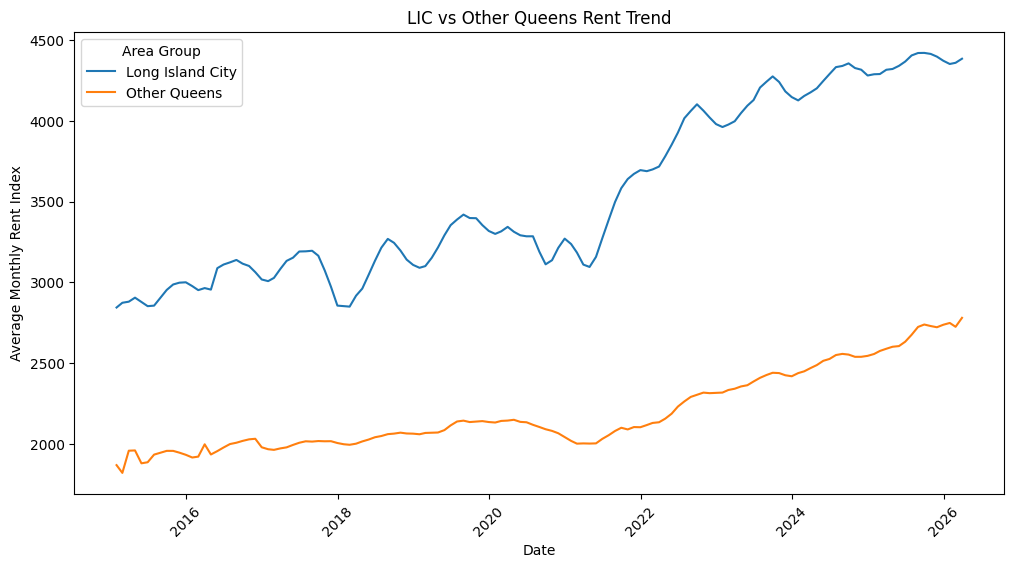

,date,area_group,avg_rent
264,2026-01-31,Long Island City,4350.075563
265,2026-01-31,Other Queens,2749.774112
266,2026-02-28,Long Island City,4357.416104
267,2026-02-28,Other Queens,2725.995268
268,2026-03-31,Long Island City,4382.671403


In [ ]:
# LIC vs other Queens rent trend
lic_queens_rent_trend = (
    lic_vs_queens
    .groupby(["date", "area_group"])
    .agg(avg_rent=("zori_rent", "mean"))
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=lic_queens_rent_trend,
    x="date",
    y="avg_rent",
    hue="area_group"
)

plt.title("LIC vs Other Queens Rent Trend")
plt.xlabel("Date")
plt.ylabel("Average Monthly Rent Index")
plt.legend(title="Area Group")
plt.xticks(rotation=45)
plt.show()

lic_queens_rent_trend[lic_queens_rent_trend["date"].dt.year == 2026].head()

**Rent distribution heatmap by borough (2026)**

This heatmap shows how 2026 rent observations are distributed across rent ranges in each borough. Manhattan has more observations in the higher rent ranges, while Queens, the Bronx, and Staten Island are mostly concentrated in lower rent ranges. This confirms that rent differences are not only about average rent, but also about how rent levels are distributed across areas.

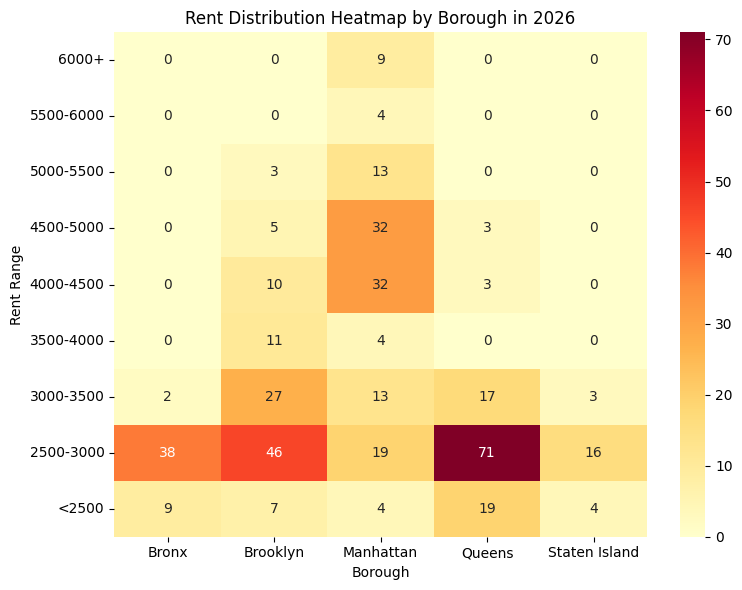

,zip_code,borough,avg_rent,zip_label
43,10282,Manhattan,7341.229587,10282 (Manhattan)
6,10007,Manhattan,7218.271090,10007 (Manhattan)
11,10013,Manhattan,6171.736032,10013 (Manhattan)
0,10001,Manhattan,5496.359172,10001 (Manhattan)
41,10162,Manhattan,5495.000000,10162 (Manhattan)
12,10014,Manhattan,5465.952742,10014 (Manhattan)
38,10069,Manhattan,5292.767359,10069 (Manhattan)
9,10011,Manhattan,5272.248918,10011 (Manhattan)
114,11249,Brooklyn,5121.253629,11249 (Brooklyn)
8,10010,Manhattan,5042.705149,10010 (Manhattan)


In [ ]:
# Rent range heatmap by borough in 2026
rent_2026 = eda_df[eda_df["year"] == 2026].copy()

rent_bins = [0, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, np.inf]
rent_labels = [
    "<2500",
    "2500-3000",
    "3000-3500",
    "3500-4000",
    "4000-4500",
    "4500-5000",
    "5000-5500",
    "5500-6000",
    "6000+"
]

rent_2026["rent_range"] = pd.cut(
    rent_2026["zori_rent"],
    bins=rent_bins,
    labels=rent_labels,
    include_lowest=True
)

rent_heatmap = pd.crosstab(
    rent_2026["rent_range"],
    rent_2026["borough"]
)

# Put higher rent ranges at the top
rent_heatmap = rent_heatmap.reindex(rent_labels[::-1])

plt.figure(figsize=(8, 6))
sns.heatmap(
    rent_heatmap,
    annot=True,
    fmt="d",
    cmap="YlOrRd"
)

plt.title("Rent Distribution Heatmap by Borough in 2026")
plt.xlabel("Borough")
plt.ylabel("Rent Range")
plt.tight_layout()
plt.show()

rent_heatmap
top_zip_heatmap_2026

### 3. Social Media Complaint Analysis

To add social context to the Zillow rent index data, we collect Reddit posts from NYC-related subreddits using rent-related search terms. We classify posts as complaints if they contain keywords such as “expensive,” “unaffordable,” “priced out,” or “too high.” We then aggregate the results by month to compare online complaint intensity with rental market trends.

* Data source: Reddit posts
* Unit: post
* Time level: month or year
* Purpose: measure rent complaint frequency and intensity

In [ ]:
!pip install praw textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 7.1 MB/s eta 0:00:00


In [ ]:
import praw
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textblob import TextBlob

# borrowing reddit from lenny
reddit = praw.Reddit(
    client_id="Q_QXuXryk45yUw",
    client_secret="V39giI7Gkf8rIB6lCaE_NcuagHs",
    user_agent="lenny",
)

print("Read only:", reddit.read_only)

Read only: True


In [ ]:
# Choose NYC-related subreddits
# These subreddits often contain discussions about NYC apartments, rent, landlords, and housing
subreddits = ["AskNYC", "NYCapartments", "nyc", "newyorkcity"]

# Search terms related to rent and housing problems
# Each query will be searched inside each subreddit
search_queries = [
    "rent",
    "apartment rent",
    "rent increase",
    "landlord",
    "broker fee",
    "lease",
    "priced out"
]

# Empty list to store all collected Reddit posts
posts = []

# Loop through each subreddit and each search term
for sub in subreddits:
    subreddit = reddit.subreddit(sub)

    for query in search_queries:
        print(f"Searching r/{sub}: {query}")

        # Search posts by keyword
        # time_filter="all" searches across all available time
        # limit=300 controls the maximum number of posts per search
        for post in subreddit.search(query, sort="new", time_filter="all", limit=300):

            # Save selected information from each post
            posts.append({
                "subreddit": sub,
                "query": query,
                "id": post.id,
                "title": post.title,
                "selftext": post.selftext,
                "created_utc": post.created_utc,
                "score": post.score,
                "num_comments": post.num_comments,
                "url": post.url
            })

# Convert collected posts into a DataFrame
reddit_df = pd.DataFrame(posts)

# Check the size and first few rows
print(reddit_df.shape)
reddit_df.head()

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Searching r/AskNYC: rent


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Searching r/AskNYC: apartment rent


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



...

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Searching r/newyorkcity: lease


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Searching r/newyorkcity: priced out
(5626, 9)


,subreddit,query,id,title,selftext,created_utc,score,num_comments,url
0,AskNYC,rent,1tajevx,"Terminating month to month, giving notice 15th...",Currently in a month to month lease. Standard ...,1.778540e+09,1,1,https://www.reddit.com/r/AskNYC/comments/1taje...
1,AskNYC,rent,1t8qrk8,Anyone know how to borrow a Gramercy Park key ...,My girlfriend and I have lived in the Gramercy...,1.778370e+09,0,30,https://www.reddit.com/r/AskNYC/comments/1t8qr...
2,AskNYC,rent,1t8ff3n,"Can I use regular rental car, e.g. Enterprise,...",I let my driver license expire for too long du...,1.778354e+09,0,33,https://www.reddit.com/r/AskNYC/comments/1t8ff...
3,AskNYC,rent,1t7on0w,Recommendations for CCL Surgery for dog,Hi hi! Sadly my dog tore her CCL (doggie ACL) ...,1.778284e+09,2,6,https://www.reddit.com/r/AskNYC/comments/1t7on...
4,AskNYC,rent,1t74q1e,"Is no buzzer and one mailbox for 3 apartments,...",I’m considering signing a lease for a newly bu...,1.778238e+09,6,20,https://www.reddit.com/r/AskNYC/comments/1t74q...


In [ ]:
# remove duplicate posts
# the same post may appear under multiple search queries
reddit_df = reddit_df.drop_duplicates(subset=["id"]).copy()

print(reddit_df.shape)
reddit_df.head()

(4146, 9)


,subreddit,query,id,title,selftext,created_utc,score,num_comments,url
0,AskNYC,rent,1tajevx,"Terminating month to month, giving notice 15th...",Currently in a month to month lease. Standard ...,1.778540e+09,1,1,https://www.reddit.com/r/AskNYC/comments/1taje...
1,AskNYC,rent,1t8qrk8,Anyone know how to borrow a Gramercy Park key ...,My girlfriend and I have lived in the Gramercy...,1.778370e+09,0,30,https://www.reddit.com/r/AskNYC/comments/1t8qr...
2,AskNYC,rent,1t8ff3n,"Can I use regular rental car, e.g. Enterprise,...",I let my driver license expire for too long du...,1.778354e+09,0,33,https://www.reddit.com/r/AskNYC/comments/1t8ff...
3,AskNYC,rent,1t7on0w,Recommendations for CCL Surgery for dog,Hi hi! Sadly my dog tore her CCL (doggie ACL) ...,1.778284e+09,2,6,https://www.reddit.com/r/AskNYC/comments/1t7on...
4,AskNYC,rent,1t74q1e,"Is no buzzer and one mailbox for 3 apartments,...",I’m considering signing a lease for a newly bu...,1.778238e+09,6,20,https://www.reddit.com/r/AskNYC/comments/1t74q...


In [ ]:
# Convert Reddit timestamp into readable datetime
reddit_df["date"] = pd.to_datetime(reddit_df["created_utc"], unit="s")

# Extract year for yearly analysis
reddit_df["year"] = reddit_df["date"].dt.year

# Extract month for monthly trend analysis
# This converts each date to the first day of that month
reddit_df["month"] = reddit_df["date"].dt.to_period("M").dt.to_timestamp()

# Combine title and body text into one text column
# This gives more complete text for keyword and sentiment analysis
reddit_df["text"] = (
    reddit_df["title"].fillna("") + " " + reddit_df["selftext"].fillna("")
)

# Lowercase version of text makes keyword matching easier
reddit_df["text_lower"] = reddit_df["text"].str.lower()

reddit_df[["subreddit", "date", "title"]].head()

,subreddit,date,title
0,AskNYC,2026-05-11 22:58:18,"Terminating month to month, giving notice 15th..."
1,AskNYC,2026-05-09 23:42:05,Anyone know how to borrow a Gramercy Park key ...
2,AskNYC,2026-05-09 19:19:34,"Can I use regular rental car, e.g. Enterprise,..."
3,AskNYC,2026-05-08 23:45:39,Recommendations for CCL Surgery for dog
4,AskNYC,2026-05-08 11:07:26,"Is no buzzer and one mailbox for 3 apartments,..."


In [ ]:
# Keywords that identify rent-related posts
rent_keywords = [
    "rent", "rental", "apartment", "lease", "landlord",
    "broker fee", "roommate", "housing"
]

# Keywords that suggest complaint or negative discussion
complaint_keywords = [
    "expensive", "unaffordable", "crazy", "insane", "ridiculous",
    "too high", "raised", "increase", "priced out",
    "can't afford", "cannot afford", "scam", "overpriced"
]

# Helper function:
# returns True if any keyword appears in the text
def contains_any_keyword(text, keywords):
    if pd.isna(text):
        return False
    return any(keyword in text for keyword in keywords)

# Create indicator for rent-related posts
# 1 / True means the post contains at least one rent keyword
reddit_df["is_rent_related"] = reddit_df["text_lower"].apply(
    lambda x: contains_any_keyword(x, rent_keywords)
)

# Create indicator for complaint posts
# 1 / True means the post contains at least one complaint keyword
reddit_df["is_complaint"] = reddit_df["text_lower"].apply(
    lambda x: contains_any_keyword(x, complaint_keywords)
)

reddit_df[["title", "is_rent_related", "is_complaint"]].head()

,title,is_rent_related,is_complaint
0,"Terminating month to month, giving notice 15th...",True,False
1,Anyone know how to borrow a Gramercy Park key ...,True,False
2,"Can I use regular rental car, e.g. Enterprise,...",True,False
3,Recommendations for CCL Surgery for dog,True,True
4,"Is no buzzer and one mailbox for 3 apartments,...",True,False


**Check how many posts are classified as complaints**

In [ ]:
reddit_df["is_complaint"].value_counts()

,count
is_complaint,
False,3036
True,1110


**Function to calculate sentiment score**

Sentiment polarity ranges from -1 to 1:

    -1 = very negative

    0 = neutral

    1 = very positive

In [ ]:
def get_sentiment(text):
    if pd.isna(text) or text.strip() == "":
        return np.nan
    return TextBlob(text).sentiment.polarity

# Apply sentiment analysis to each post
reddit_df["sentiment"] = reddit_df["text"].apply(get_sentiment)

reddit_df[["title", "sentiment"]].head()

,title,sentiment
0,"Terminating month to month, giving notice 15th...",-0.145833
1,Anyone know how to borrow a Gramercy Park key ...,0.104167
2,"Can I use regular rental car, e.g. Enterprise,...",0.021591
3,Recommendations for CCL Surgery for dog,0.052381
4,"Is no buzzer and one mailbox for 3 apartments,...",-0.012072


In [ ]:
# Aggregate Reddit data by month
# This creates one row per month
reddit_monthly = (
    reddit_df
    .groupby("month")
    .agg(
        reddit_post_count=("id", "count"),
        rent_related_count=("is_rent_related", "sum"),
        complaint_count=("is_complaint", "sum"),
        avg_sentiment=("sentiment", "mean"),
        avg_score=("score", "mean"),
        avg_comments=("num_comments", "mean")
    )
    .reset_index()
)

# Complaint share = complaint posts divided by all collected posts in that month
reddit_monthly["complaint_share"] = (
    reddit_monthly["complaint_count"] / reddit_monthly["reddit_post_count"]
)

reddit_monthly.head()

,month,reddit_post_count,rent_related_count,complaint_count,avg_sentiment,avg_score,avg_comments,complaint_share
0,2010-06-01,2,2,1,0.253499,14.5,33.5,0.5
1,2010-08-01,2,2,2,0.128113,21.5,40.0,1.0
2,2010-11-01,1,1,0,0.413889,13.0,27.0,0.0
3,2010-12-01,2,2,2,0.109526,16.0,39.0,1.0
4,2011-01-01,1,1,1,0.132481,2.0,24.0,1.0


**Plot monthly complaint count**

  Reddit rent complaint posts stay very low before 2020, then rise sharply after 2022 and peak around 2025–2026, suggesting that online discussion about NYC rent became much more active in recent years.

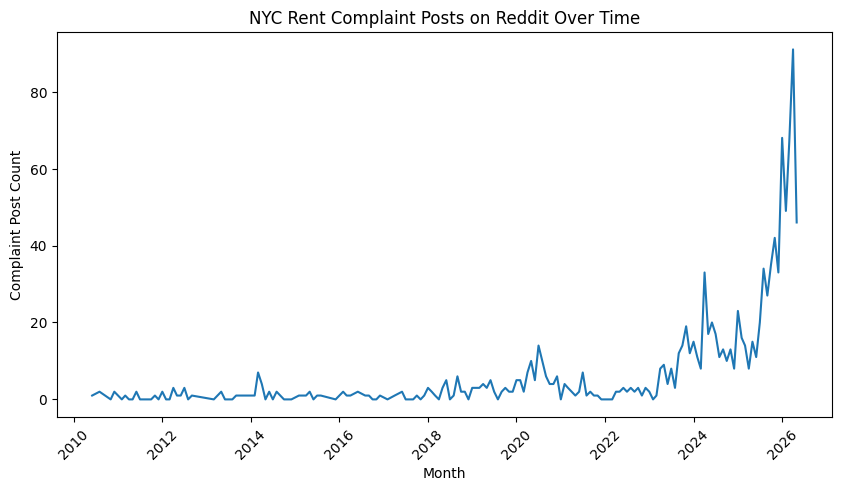

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(reddit_monthly["month"], reddit_monthly["complaint_count"])
plt.title("NYC Rent Complaint Posts on Reddit Over Time")
plt.xlabel("Month")
plt.ylabel("Complaint Post Count")
plt.xticks(rotation=45)
plt.show()

**Plot complaint share over time**

  The complaint share is very unstable in earlier years because there were few posts, but after 2022 it becomes more meaningful and generally shows that a sizable portion of rent-related posts are complaints.

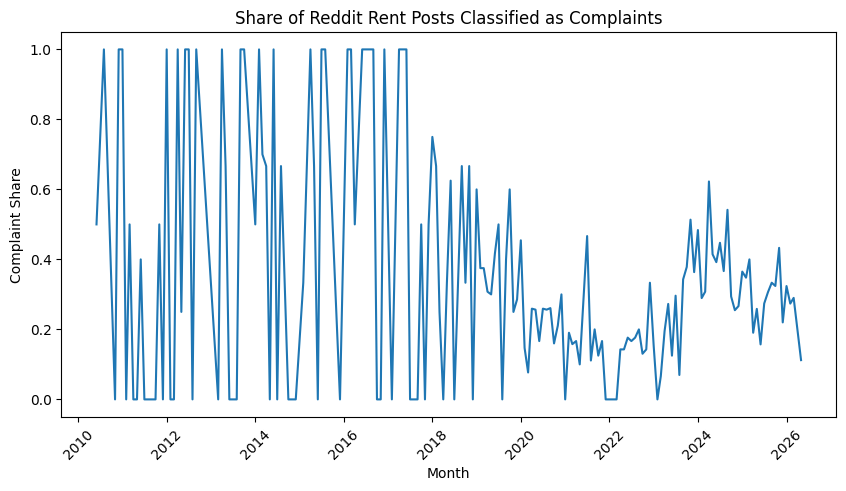

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(reddit_monthly["month"], reddit_monthly["complaint_share"])
plt.title("Share of Reddit Rent Posts Classified as Complaints")
plt.xlabel("Month")
plt.ylabel("Complaint Share")
plt.xticks(rotation=45)
plt.show()

**Plot average sentiment over time**

A lower score means posts are more negative on average.     Average sentiment stays mostly near or slightly above zero, with occasional negative spikes, suggesting that TextBlob sentiment does not capture rent frustration as clearly as the keyword-based complaint count

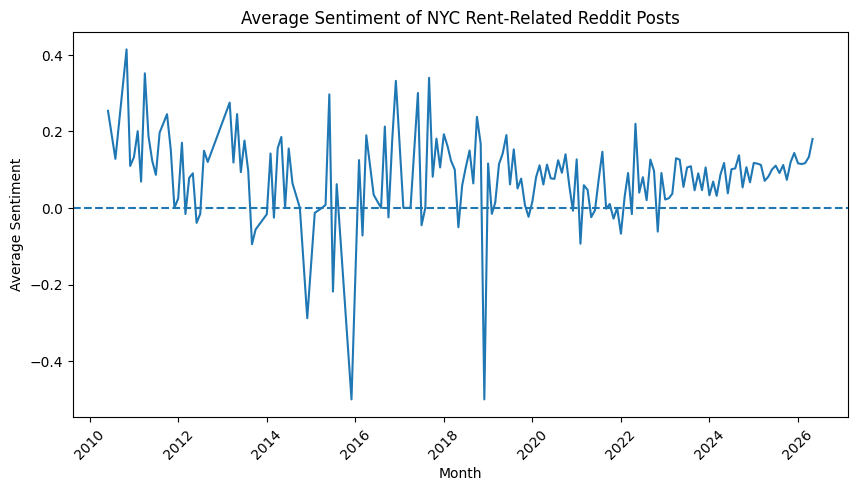

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(reddit_monthly["month"], reddit_monthly["avg_sentiment"])
plt.axhline(0, linestyle="--")
plt.title("Average Sentiment of NYC Rent-Related Reddit Posts")
plt.xlabel("Month")
plt.ylabel("Average Sentiment")
plt.xticks(rotation=45)
plt.show()

***Note:** We tried to merge the ZORI data frame with the scrapped reddit one, but found there's no data point on a same datetime in common. Merge data frame becomes empty.

### 4. Hypothesis

* Manhattan has the highest rent level.

* LIC has higher rent than many other Queens ZIP codes.

* Recent rent values are strong predictors of next month’s rent.

* 12-month lag captures yearly seasonality.

* Models with lag features should outperform a simple baseline.